The breast cancer Wisconsin Diagnostic dataset was downloaded from kaggle. This dataset is designed to predict whether a breast tumor is malignant or benign based on cell nucleus features extracted from medical images. These features were computed from a digitized image of a Fine Needle Aspirate (FNA) of a breast mass. It consists of 30 different features and each describes the characteristics of the cell nuclei such as radius_mean, texture_mean, area_mean etc

✅ **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

**✅ Load & Clean Data**

In [ ]:
df = pd.read_csv("data.csv")

df = df.drop(columns=["id", "Unnamed: 32"])

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print(X.shape)

(569, 30)


Here,

1 represents cancer present(Malignant) → Positive

0 represents cancer absent(Benign) → Negative

**✅ Exploratory Data Analysis (EDA) (Correlational heat Map)**

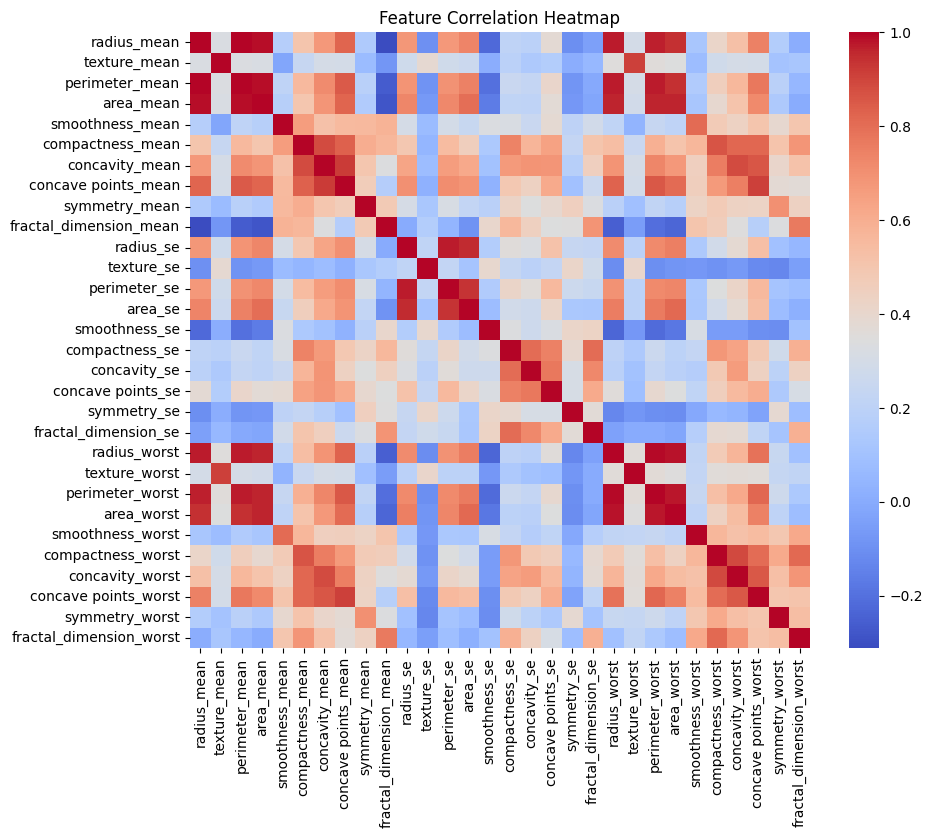

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

✅ **PCA** **Visualization**

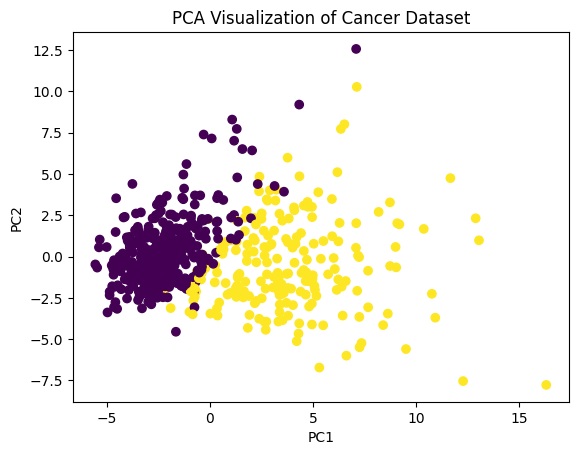

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA Visualization of Cancer Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Purple corresponds to label 0(Benign) and yellow corresponds to label 1(Malignant). The PCA plot shows that benign tumors form a compact cluster on the left side (negative PC1), while malignant tumors are more dispersed on the right side (positive PC1) reflecting higher heterogeneity

✅ **Cross-Validation BEFORE Train-Test Split**

In [ ]:
from sklearn.impute import SimpleImputer # New import for handling missing values

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

print("Cross Validation Results (10-Fold):\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), # Added imputer to handle NaNs
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')

    print(f"{name}:")
    print("Mean Accuracy:", scores.mean())
    print("Std Dev:", scores.std())
    print("-------------")

Cross Validation Results (10-Fold):

Logistic Regression:
Mean Accuracy: 0.9754385964912279
Std Dev: 0.01953601530817553
-------------
SVM:
Mean Accuracy: 0.9754385964912281
Std Dev: 0.019536015308175527
-------------
Random Forest:
Mean Accuracy: 0.9508771929824562
Std Dev: 0.029146048641817822
-------------
KNN:
Mean Accuracy: 0.9701441102756894
Std Dev: 0.01760977703284993
-------------


**✅ Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)




The dataset consists of 569 patients where 357 have Benign and 212 are Malignant. So 114(20%) of the patients are kept in test set and 455(80%) of the patients are kept in training set

Approximate Distribution After Split:

**🟢 Training Set (455 patients)**

~286 Benign

~169 Malignant

**🟢 Test Set (114 patients)**

~71 Benign

~43 Malignant

**✅ Create Pipelines for Multiple Models**

In [ ]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier())
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

**✅ Train All Models & Compare Performance**

In [ ]:
results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "ROC-AUC": roc_auc
    })

    print(f"\n{name}")
    print("Accuracy:", accuracy)
    print("ROC-AUC:", roc_auc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9649122807017544
ROC-AUC: 0.996031746031746
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


SVM
Accuracy: 0.9736842105263158
ROC-AUC: 0.9947089947089947
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Random Forest
Accuracy: 0.9649122807017544
ROC-AUC: 0.994212962962963
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00    

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.964912,0.996032
3,Gradient Boosting,0.964912,0.995370
1,SVM,0.973684,0.994709
2,Random Forest,0.964912,0.994213
4,KNN,0.956140,0.982308


**✅ Collect ALL Evaluation Metrics**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "ROC-AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy   ROC-AUC  Precision    Recall  F1-Score
0  Logistic Regression  0.964912  0.996032   0.965185  0.964912  0.964725
1                  SVM  0.973684  0.994709   0.974737  0.973684  0.973465
2        Random Forest  0.964912  0.994213   0.966759  0.964912  0.964509
3    Gradient Boosting  0.964912  0.995701   0.966759  0.964912  0.964509
4                  KNN  0.956140  0.982308   0.956869  0.956140  0.955776


✅ **Comparative Bar Graph for all the statistical parameters for each model**

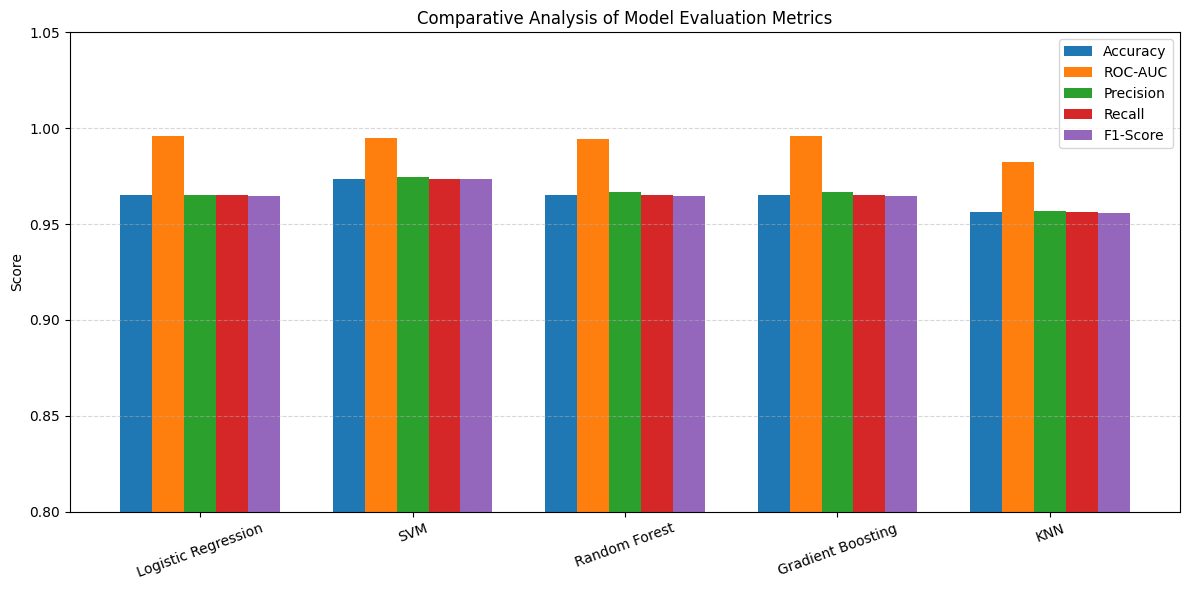

In [ ]:
metrics = ["Accuracy", "ROC-AUC", "Precision", "Recall", "F1-Score"]

x = np.arange(len(results_df["Model"]))
width = 0.15

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xticks(x + width*2, results_df["Model"], rotation=20)
plt.ylabel("Score")
plt.title("Comparative Analysis of Model Evaluation Metrics")
plt.ylim(0.8, 1.05)   # Adjust based on your scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**✅ Plot ROC Curves**

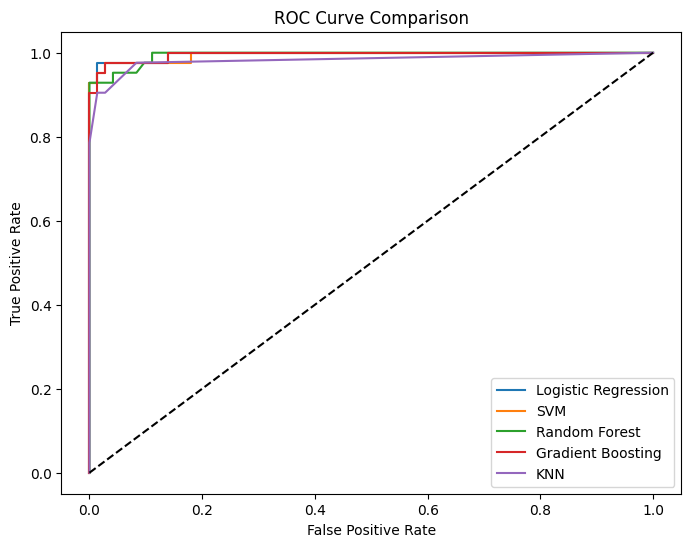

In [ ]:
plt.figure(figsize=(8,6))

for name, pipeline in pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

From the above analysis, the best performing model is SVM, since it has highest accuracy, F1 score, Precision and Recall.

✅ **Cross checking that SVM is the best model**



In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

# Define best_svm from the existing pipelines dictionary
best_svm = pipelines["SVM"]

scores = cross_val_score(best_svm, X, y, cv=rkf, scoring='roc_auc')

print("Mean ROC-AUC:", scores.mean())
print("Std Dev:", scores.std())

Mean ROC-AUC: 0.9955797430083143
Std Dev: 0.005920570302248592


The standard deviation is 0.005, which means that model is highly reliable

**✅ Permutation Importance of SVM**


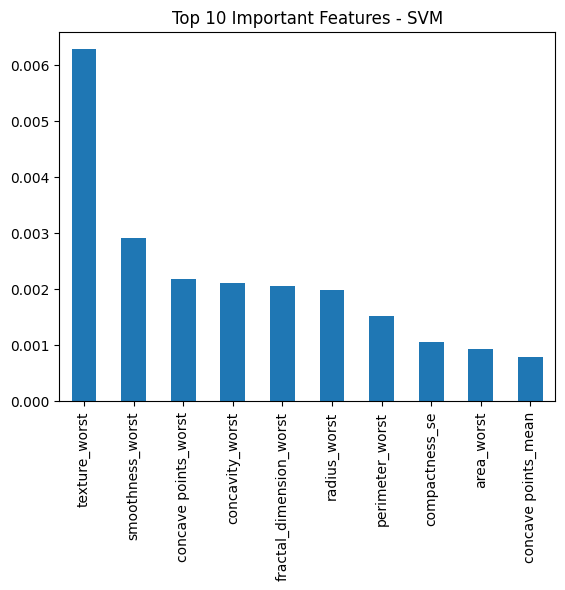

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    best_svm, X_test, y_test, scoring='roc_auc'
)

importance = pd.Series(result.importances_mean, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features - SVM")
plt.show()

The best trained SVM was used with the test data. The importance was measured on the basis of ROC-AUC curve and each feature was shuffled one by one by measuring how much ROC-AUC drops. It was seen from the graph that the feature_worst has the highest importance, suggesting that if this feature is shuffled, then ROC-AUC drops the maximum. Permutation importance analysis revealed that worst-case morphological features, particularly texture_worst, contributed most significantly to the predictive performance of the SVM model

**✅ Confusion Matrix**

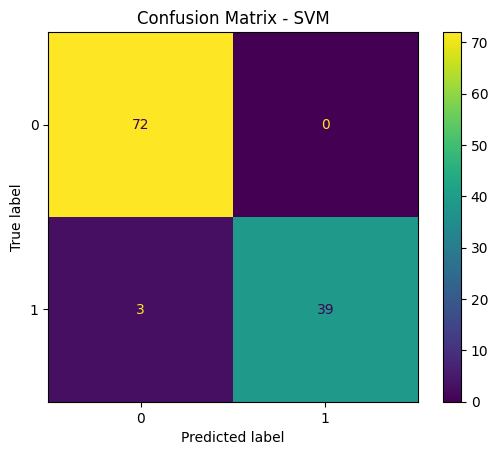

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("data.csv")

# Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert target
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Define features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
best_svm = SVC(kernel='rbf')
best_svm.fit(X_train, y_train)

# Predict
y_pred = best_svm.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

plt.title("Confusion Matrix - SVM")
plt.show()

Confusion matrix shows that 72 benign tumors are correctly predicted as benign (TN) and 0 benign tumour is inaccurately predicted as malignant (FP). 3 malignant tumors were predicted as benign (FN). 39 malignant tumors are correctly predicted (TP)

**✅Parameter Calculations after Confusion matrix**

**1. Accuracy**
=(TP+TN)/(TP+TN+FP+FN)

39+72/72+39+0+3
=97%

**2. Sensitivity**
=TP/(TP+FN)

39/(39+3)
=92.86%

**3. Specificity**
TN/(TN+FP)
72/72+0
=100%

The SVM classifier achieved an overall accuracy of 97.36%. The model demonstrated perfect specificity (100%), correctly classifying all benign cases with efficacy. Sensitivity for malignant detection was 92.86% where 3 samples were wrongly predicted as Benign